# CHIEN VS CHAT FROM SCRATCH: 
### Un Modèle de DeepLearning de CNN qui differencie le CHIEN de CHAT
il s'agit d'un modèle de deeplearning qui met la differnce entre le chien et le chat , donc ça été entraîné pour reconnaître le chien et le chat a été entraîné sur 1000 photos dont 500 pour l'entraînement et 500 pour le test 

* Le but etait de faire un CNN(convolutional neuronal Network) **`from scratch`** fonctionnel en utilisant les **`Maths`** donc sans les bibliotheques de Deeplearng comme `Tensorflow` ,`pytorch` ,`keras` , mais aussi `opencv`(la vision par ordinateur ) pour le traitement d'images ceux dont on a juste utilisé pour creer le reseau de neurones des Convolutions c'est `numpy` , `scipy` et `PIl` pour charger le dataset qui contient les images

###  PIPE LINE 
* Charger les images et les redimensionner
* Initialiser les paramètres (Xavier)
* Créer la fonction de Convolution
* Créer la matrice de Pooling
* Créer les fonctions d'activation  comme relu et signoid
* Faire la retropropagation sens aller sens retour pour mettre a jour le filtre de convoution ainsi que les paramètres comme les Biais et les Poids
* Tester le modele sur les nouvelles images qu'elle n'a jamais
---

# CHIEN VS CHAT FROM SCRATCH 

Entraînement : 500 images | Test : 500 images
Époque 0 terminée. Erreur moyenne : 0.2510
Époque 20 terminée. Erreur moyenne : 0.1024
Époque 40 terminée. Erreur moyenne : 0.0706


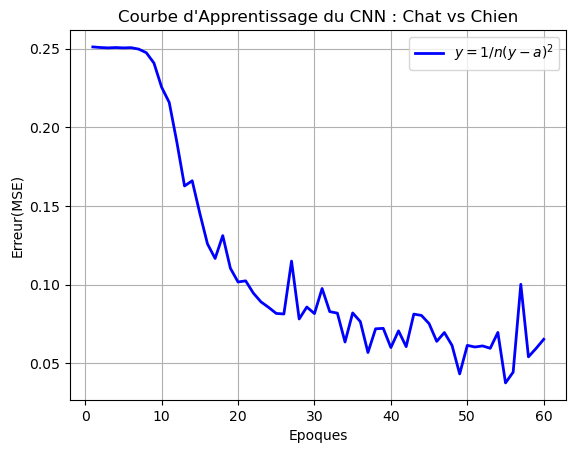

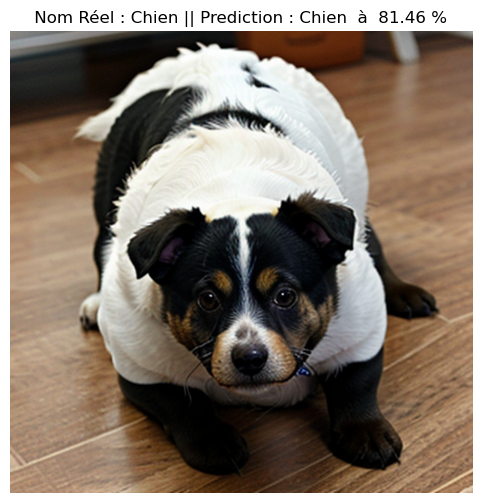

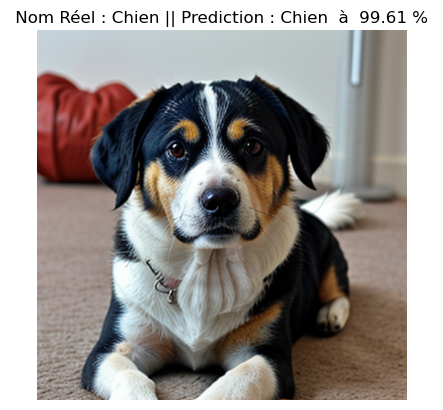

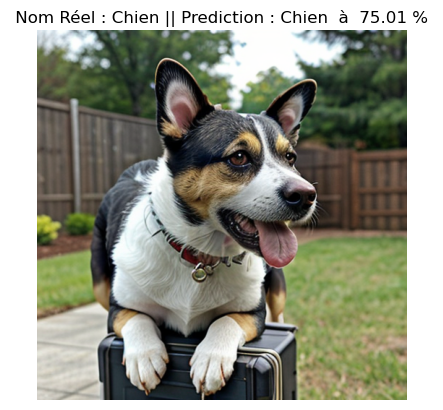

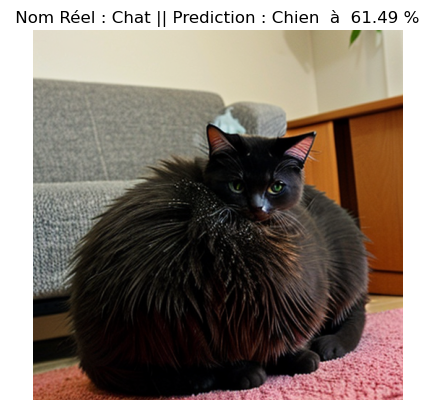

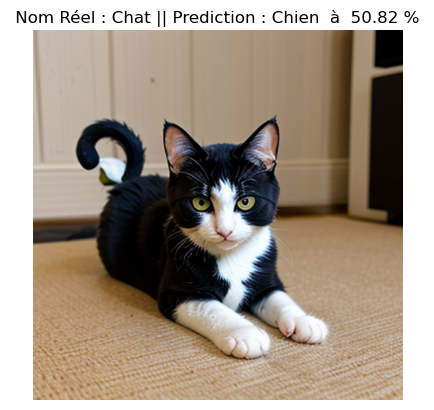

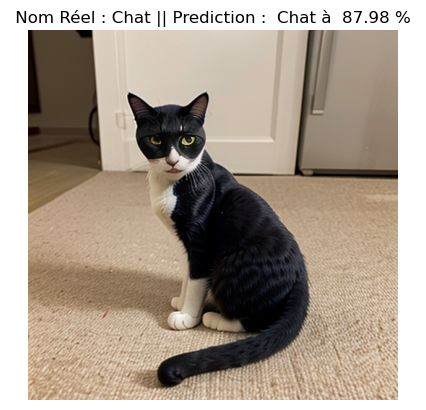

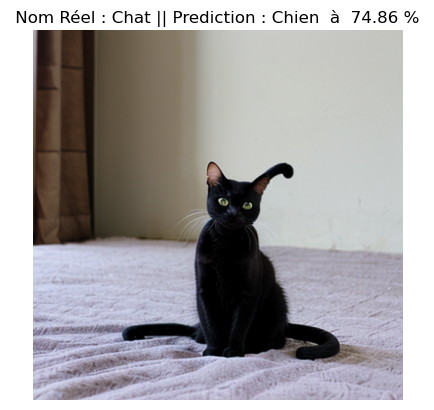

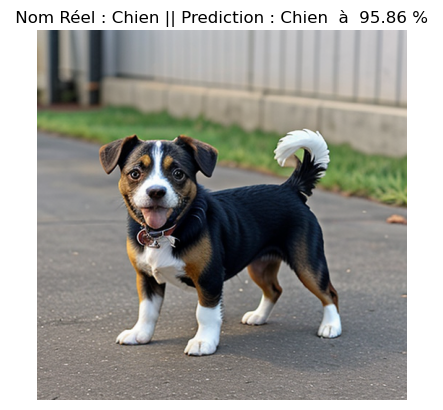

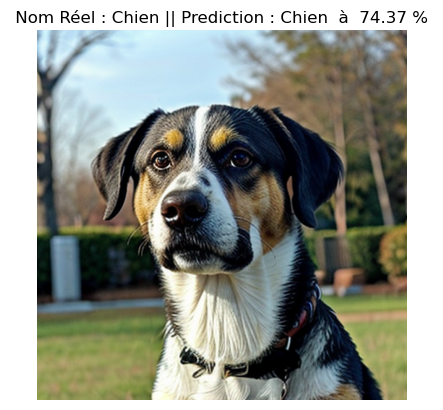

In [ ]:
import os 
import random
import zipfile
import numpy as np
from PIL import Image
from scipy import signal 
import matplotlib.pyplot as plt

## PIL ,numpy ,matplotlib ,scipy sont à installer sur anaconda taper : conda install nom_du_package(donc numpy ,pillow ,scipy , etc)


with zipfile.ZipFile('dataset.zip' , 'r') as zip_ref : 
    zip_ref.extractall('my_cnn')
    
path_link = 'my_cnn'
folder_cat = os.path.join(path_link , 'cat')
folder_dog = os.path.join(path_link , 'dog')

# 1. 
all_cats = [os.path.join(folder_cat, f) for f in os.listdir(folder_cat) if f.lower().endswith(('.png', '.jpg', '.jpeg')) and not f.startswith('.')]
all_dogs = [os.path.join(folder_dog, f) for f in os.listdir(folder_dog) if f.lower().endswith(('.png', '.jpg', '.jpeg')) and not f.startswith('.')]

# 2. Mélanger aléatoirement 
random.shuffle(all_cats)
random.shuffle(all_dogs)

# 3. 500 images pour l'entrainement et 500 pour le test
train_size = 250 

train_data = []
for f in all_cats[:train_size]: train_data.append((f, 1))
for f in all_dogs[:train_size]: train_data.append((f, 0))

test_data = []
for f in all_cats[train_size:]: test_data.append((f, 1))
for f in all_dogs[train_size:]: test_data.append((f, 0))

# Mélanger les sets finaux
random.shuffle(train_data)
random.shuffle(test_data)

print(f"Entraînement : {len(train_data)} images | Test : {len(test_data)} images")
## Initilalisations des paramètres 
n_neurones = 10 
n_filtres  = 8
lr = 0.01

W_1 = np.random.randn(n_neurones ,n_filtres*14*14)*np.sqrt(2.0/(n_neurones +n_filtres*14*14))
W_2 = np.random.randn(1 , n_neurones)*np.sqrt(2.0/(1+n_neurones))
W_filtre = np.random.randn(n_filtres , 3 , 3)*np.sqrt(2.0/(n_filtres+9))

B_1 = np.zeros((n_neurones ,1))
B_2 = 0
## fonction relu
def relu(x) : 
    return np.maximum(0 ,x)

## fonction signoid
def signoid(x): 
    return 1/(1+np.exp(-x))

# le produit de convolution    
def convolution(A ,M) : 
    conv = []
    for i in range(n_filtres) : 
        Z = signal.convolve2d(A , M[i] , boundary='fill' ,mode='same')
        conv.append(Z)
    return np.array(conv)   
## matrice de pooling
def pooling(x) : 
    pool = []
    for k in range(n_filtres) : 
        x_now = x[k]
        P = np.zeros((14 ,14))
        for i in range(14) : 
            for j in range(14): 
                P[i ,j] = np.max(x_now[2*i : (2*i)+2 , 2*j : (2*j)+2])
        pool.append(P) 
    return np.array(pool)
    
epochs = 60 # 40 a marche a marche aussi 
compteur = 0

liste_epoques = []
loss_moyenne = []
## reseaux de neurones
for i in range(epochs) : 
    random.shuffle(train_data)

    erreur_totale_epoque = 0 
    nb_images = 0

    

    for chemin , prediction in (train_data)[ : len(train_data)] : 
        try : 
            if not chemin.lower().endswith(('.png' , '.jpeg' , '.jpg')) : 
                continue

            image = Image.open(chemin).convert('L')
            image_resize = image.resize((28 ,28))
            image_array  = np.array(image_resize)/255.0

            X_conv = convolution(image_array , W_filtre)
            X_relu = relu(X_conv)
            X_pool = pooling(X_relu)
            X_input = X_pool.flatten().reshape(-1 ,1)

            Z_1 = W_1 @ X_input + B_1
            A_1 = relu(Z_1)

            Z_2 = W_2 @ A_1 + B_2
            A_2 = signoid(Z_2)
            
             
            erreur_image = np.square(A_2[0][0]-prediction)
            erreur_totale_epoque += erreur_image
            nb_images += 1 

            dZ_2 = A_2 - prediction 
            dZ_1 = (W_2.T @ dZ_2)*(Z_1 >0)

            dX_pool = (W_1.T @ dZ_1).reshape(n_filtres ,14 ,14)

            mask_3d = np.zeros((n_filtres ,28 ,28))
            for p in range (n_filtres) : 
                for k in range (14) : 
                    for m in range(14): 
                        block = X_conv[p , 2*k : (2*k)+2 , 2*m : (2*m)+2]
                        mask = (block == np.max(block))
                        mask_3d[p , 2*k : (2*k)+2 , 2*m : (2*m)+2] = mask 

            dX_conv = np.repeat(np.repeat(dX_pool , 2 ,axis=1) , 2 ,axis=2) * mask_3d
            
            dW_filtre = np.zeros_like(W_filtre)
            
            for h in range(n_filtres): 

                dW_filtre[h] = signal.convolve2d(image_array , dX_conv[h] , mode='valid')
                        
            dW_2 = dZ_2 @ A_1.T
            dW_1 = dZ_1 @ X_input.T 
            
            dB_2 = dZ_2
            dB_1 = dZ_1

            W_1 -= lr*dW_1
            W_2 -= lr*dW_2
            
            W_filtre -= lr*dW_filtre

            B_1 -= lr*dB_1 
            B_2 -= lr*dB_2 
        
    
        except PermissionError : 
            print(f"file not found")

    
    loss_moyenne.append(erreur_totale_epoque/nb_images) 
    liste_epoques.append(i+1)

    if i % 20 == 0 :
        print(f"Époque {i} terminée. Erreur moyenne : {loss_moyenne[i]:.4f}")
    
## Test sur le modele sur les images qu'elle n'a pas vu pendant son entrainemnt 
def prediction_newdata(chemin_image , W_filtre , W_1 ,W_2 , B_1 , B_2) : 
    
    image = Image.open(chemin_image).convert('L')
    image_resize = image.resize((28 ,28))
    image_array  = np.array(image_resize)/255.0

    X_conv = convolution(image_array , W_filtre)
    X_relu = relu(X_conv)
    X_pool = pooling(X_relu)
    X_input = X_pool.flatten().reshape(-1 ,1)

    Z_1 = W_1 @ X_input + B_1
    A_1 = relu(Z_1)

    Z_2 = W_2 @ A_1 + B_2
    A_2 = signoid(Z_2)

    return A_2[0][0]

plt.title(f"Courbe d'Apprentissage du CNN : Chat vs Chien")
plt.plot(liste_epoques , loss_moyenne ,label='$y=1/n(y-a)^2$' ,color='blue' ,lw=2)
plt.grid(True)
plt.xlabel('Epoques')
plt.ylabel('Erreur(MSE)')
plt.legend()
plt.show()

nb_images_test = 50  ## on va afficher que 20 images pour voir la precision de notre modele 

plt.figure(figsize =(12 ,6))

for i in range(nb_images_test) : 
    

    chemin_image , prediction_reelle = random.choice(test_data)  

    score = prediction_newdata(chemin_image ,W_filtre , W_1 ,W_2 , B_1 , B_2)
    if score > 0.50 : 
        name_animale = " Chat"
        prediction_finale = (score)*100 
    else :
        name_animale = "Chien "
        prediction_finale = (1-score)*100 
    

    true_name = "Chat" if prediction_reelle == 1 else "Chien"
    
    plt.title(f" Nom Réel : {true_name} || Prediction : {name_animale} à {prediction_finale : .2f} % ")
    plt.imshow(Image.open(chemin_image) ,cmap='gray')
    plt.axis('off')
    plt.show()


# Les Mathématiques de Réseaux de Neurones des Convolutions (Convolutional Neuronal Network)
*  **Le Produit de Convolution**: Soit 2 matrices dont l'une est l'entrée ( la photo de chien ou de chat) qui sera envoyé dans le RN et son Motif le filtre ce produit est : $$ C_p = \sum_{i=0}^{n} A_i \cdot M_{i+p} $$ $n$ est la taille de $A$ à ce stade on regarde les pixels qui ont beaucoup contribué ca veut plus ce produit est important plus cette information est nécessaire
*  **Matrice de Pooling** : C'est une matrice qui a souvent comme taille  la moitié de la matrice de l'entrée (la photo) on la reduit à cette taille pour faciliter les calculs mais aussi pour dimunuer les parametres de notre modèle , ici on divise la matrice d'entrée des petites matrice de taille (p $times$ p) et prendre le max de cette sous matrice avec p est le pas souvent le pas de 2 pour ne pas perdre beaucoup d'information sur l'image | Alors pour une matrice $P$ de $i$ ligne et $j$ colonnes cette matrice est :
`P_{ij} = max(E[pi : pi+p ,pj : pj+p])` 
avec $p$ le pas , $E$ la matrice resultat de la convolution  
*   **Activation de Relu** : C'est une fonction qui fait passer les entrées positives et bloquer les entrées negatives est donnée par la relation pour une entrée $X$ comme `Relu(X) = max(0 , X)`
### Le Réseau de Convolution 
* **Calcul de la Somme pondéré** : La sortie est la combinaison lineaire de l'entrée ajouté du bias $$ Z = W \cdot X + B $$ Avec X l'image donc la photo car celle ci est une matrice et $W$ et $B$ ce sont les paramètres qu'on cherche quand on entraîne le modèle de l'intelligence artificielle , ça veut dire quand on entraîne un modèle de IA ce sont ces parameters que on cherche donc on va chercher quelle est la valeur de $W$ et $B$ qui minimise l'erreur
* **Fonction Signoid** : C'est une fonction qui transforme tout en une probabilité,pour une entrée $X$ elle est donnée par la relation : $$\sigma(x)=\frac{1}{1+e^{-x}}$$
*  **Fonction de Coût** : C'est ça la fonction qu'on cherche à munimiser , pour notre cas cette foncton est la loi de Bernoulli  qui predit l'echec(le chien) ou le reusiite(le chat) donc si $Y=0$ c'est l'Echec et si $Y=1$ reussite il s'agit de l'apprentissage supervisé. Pour un evenement $Y$ de probabilité $a$  cette fonction est donnée par $$L=Y \cdot ln(a)+(1-Y) \cdot ln(1-a) $$ au fait on y met les $ln$ pour que cette valeur soit stocker par l'ardinateur mais elle n'a pas ces $log$ C'est cette fonction qu'on cherche a munimiser par rapport aux parametres du modele donc on calcule les gradients(car c'est la derivee d'un scaleur par rapport aux vecteurs voir même les tenseurs )
*  **Retropropagation** : c'est la Descente de Gradient appliquée aux Réseaux de Neurones au fait cette formule est le developpement de Mac laurin ou la Methode de Newton et est donnée par : $$ W = W - \alpha \cdot \frac{\partial L}{\partial W}$$ $$ B = B - \alpha \cdot \frac{\partial L}{\partial B}$$
*  **Tester le modele** : sur le données qu'elle n'a jamais vu Ce qui se passe a ce stade , quand on donne au modele la photo de chien ou chat pour savoir s'il s'agit de quoi ,on ne calcule que cette somme pondered $Z$ avec les parametre $W$ et $B$ trouvés lors de l'entraînement si elle tend vers $1$ alors c'est le chat dans le cas contraire c'eest le chien 

In [13]:
import numpy as np
import os

# Création du dossier sur ton disque dur
cat_vs_dog_PARAMETRES = 'poids_cat_dog'
if not os.path.exists(cat_vs_dog_PARAMETRES):
    os.makedirs(cat_vs_dog_PARAMETRES)

# Sauvegarde des matrices NumPy
np.save(f'{dossier_poids}/W_1.npy', W_1)
np.save(f'{dossier_poids}/W_2.npy', W_2)
np.save(f'{dossier_poids}/W_filtre.npy', W_filtre)
np.save(f'{dossier_poids}/B_1.npy', B_1)
np.save(f'{dossier_poids}/B_2.npy', np.array([B_2]))

print(f"✅ Paramètres sauvegardés dans le dossier : {os.path.abspath(cat_vs_dog_PARAMETRES)}")

✅ Paramètres sauvegardés dans le dossier : C:\Users\gloir\__AI_2026_GLOIRE\CNN__DEEPMATH\MyProjectAI_CNN\poids_cat_dog
